In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_orders.csv", parse_dates=["Order_Date", "Ship_Date"])
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


> + Most Used Shipping Mode

Ship_Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


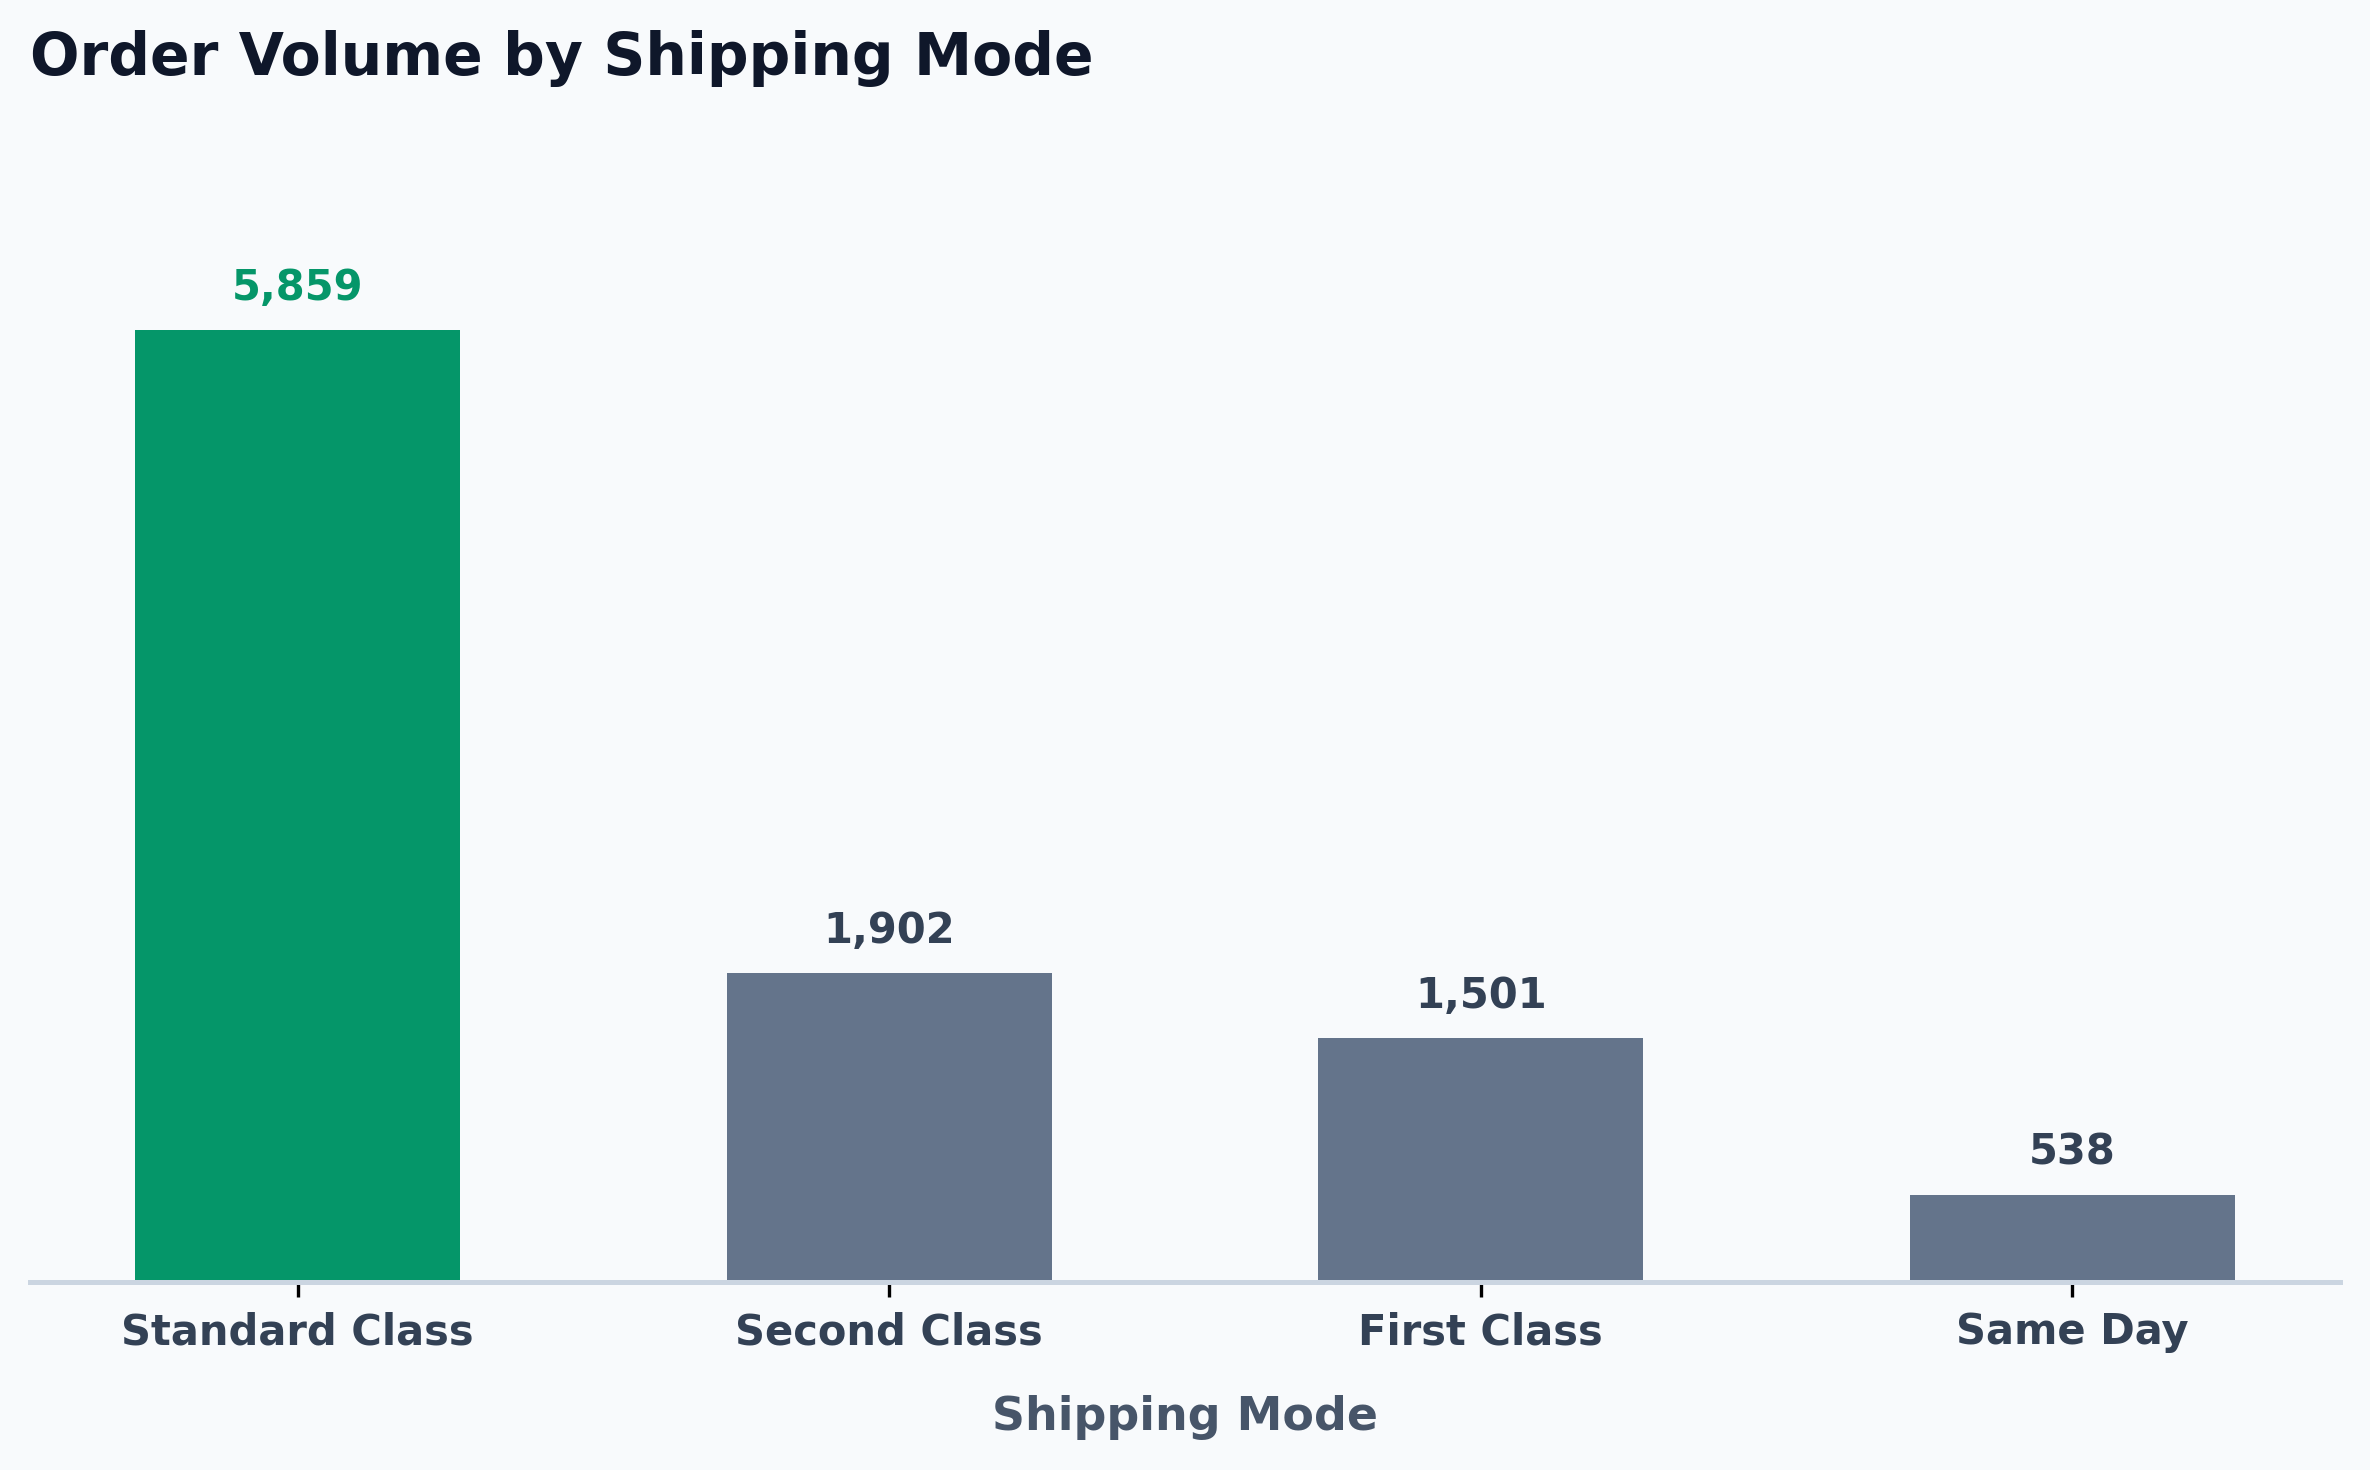

In [4]:
# 1. Calculate Shipping Mode Frequency
shipmode_counts = df["Ship_Mode"].value_counts()
print(shipmode_counts)

# 2. Dynamic Highlight Colors (Rank 1 = Emerald Green, Rest = Slate)
max_val = shipmode_counts.max()
bar_colors = ["#059669" if val == max_val else "#64748B" for val in shipmode_counts.values]

# 3. Setup Figure with Soft Executive Card Background
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 4. Bar Plot
bars = ax.bar(
    shipmode_counts.index,
    shipmode_counts.values,
    color=bar_colors,
    width=0.55,
    edgecolor="none"
)

# 5. Bar Value Labels (Direct Numbers on Top)
ax.bar_label(
    bars,
    labels=[f"{x:,}" for x in shipmode_counts.values],
    padding=5,
    fontsize=10,
    fontweight="bold"
)

# Color Top Bar Label Emerald Green
for text, val in zip(ax.texts, shipmode_counts.values):
    if val == max_val:
        text.set_color("#059669")
    else:
        text.set_color("#334155")

# 6. Spines & Axes Formatting
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CBD5E1")
ax.spines["bottom"].set_linewidth(1.2)

# Hide the redundant Y-axis because direct count labels are displayed
ax.get_yaxis().set_visible(False)
ax.set_ylim(0, max_val * 1.18)

plt.xticks(rotation=0, fontsize=10, fontweight="bold", color="#334155")

# 7. Title & Axis Labels
plt.title(
    "Order Volume by Shipping Mode", 
    fontsize=14, 
    fontweight="bold", 
    color="#0F172A",
    pad=20, 
    loc="left"
)
plt.xlabel("Shipping Mode", fontsize=11, fontweight="bold", color="#475569", labelpad=10)

# Minimal Grid
plt.grid(axis="y", linestyle="--", alpha=0.5, color="#E2E8F0")

# 8. Save & Display (Retaining Card Background)
plt.tight_layout()
plt.savefig(
    "../reports/charts/shipmode_counts.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight"
)

plt.show()

In [5]:
# Calculate total sales for each shipping mode and sort from highest to lowest
shipmode_sales = df.groupby("Ship_Mode")["Sales"].sum().sort_values(ascending=False)
print(shipmode_sales)

Ship_Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


> + Delivery Time Calculation

In [6]:
# Calculate the number of days between the order date and shipping date
df["Delivery_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

# Display summary statistics for delivery days
print(df["Delivery_Days"].describe())

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Delivery_Days, dtype: float64


- Average delivery time overall:

In [7]:
# Calculate the average delivery time in days
avg_delivery = df["Delivery_Days"].mean()

print(f"Average delivery time: {avg_delivery:.2f} days")


Average delivery time: 3.96 days


> + Delivery time distribution (histogram)

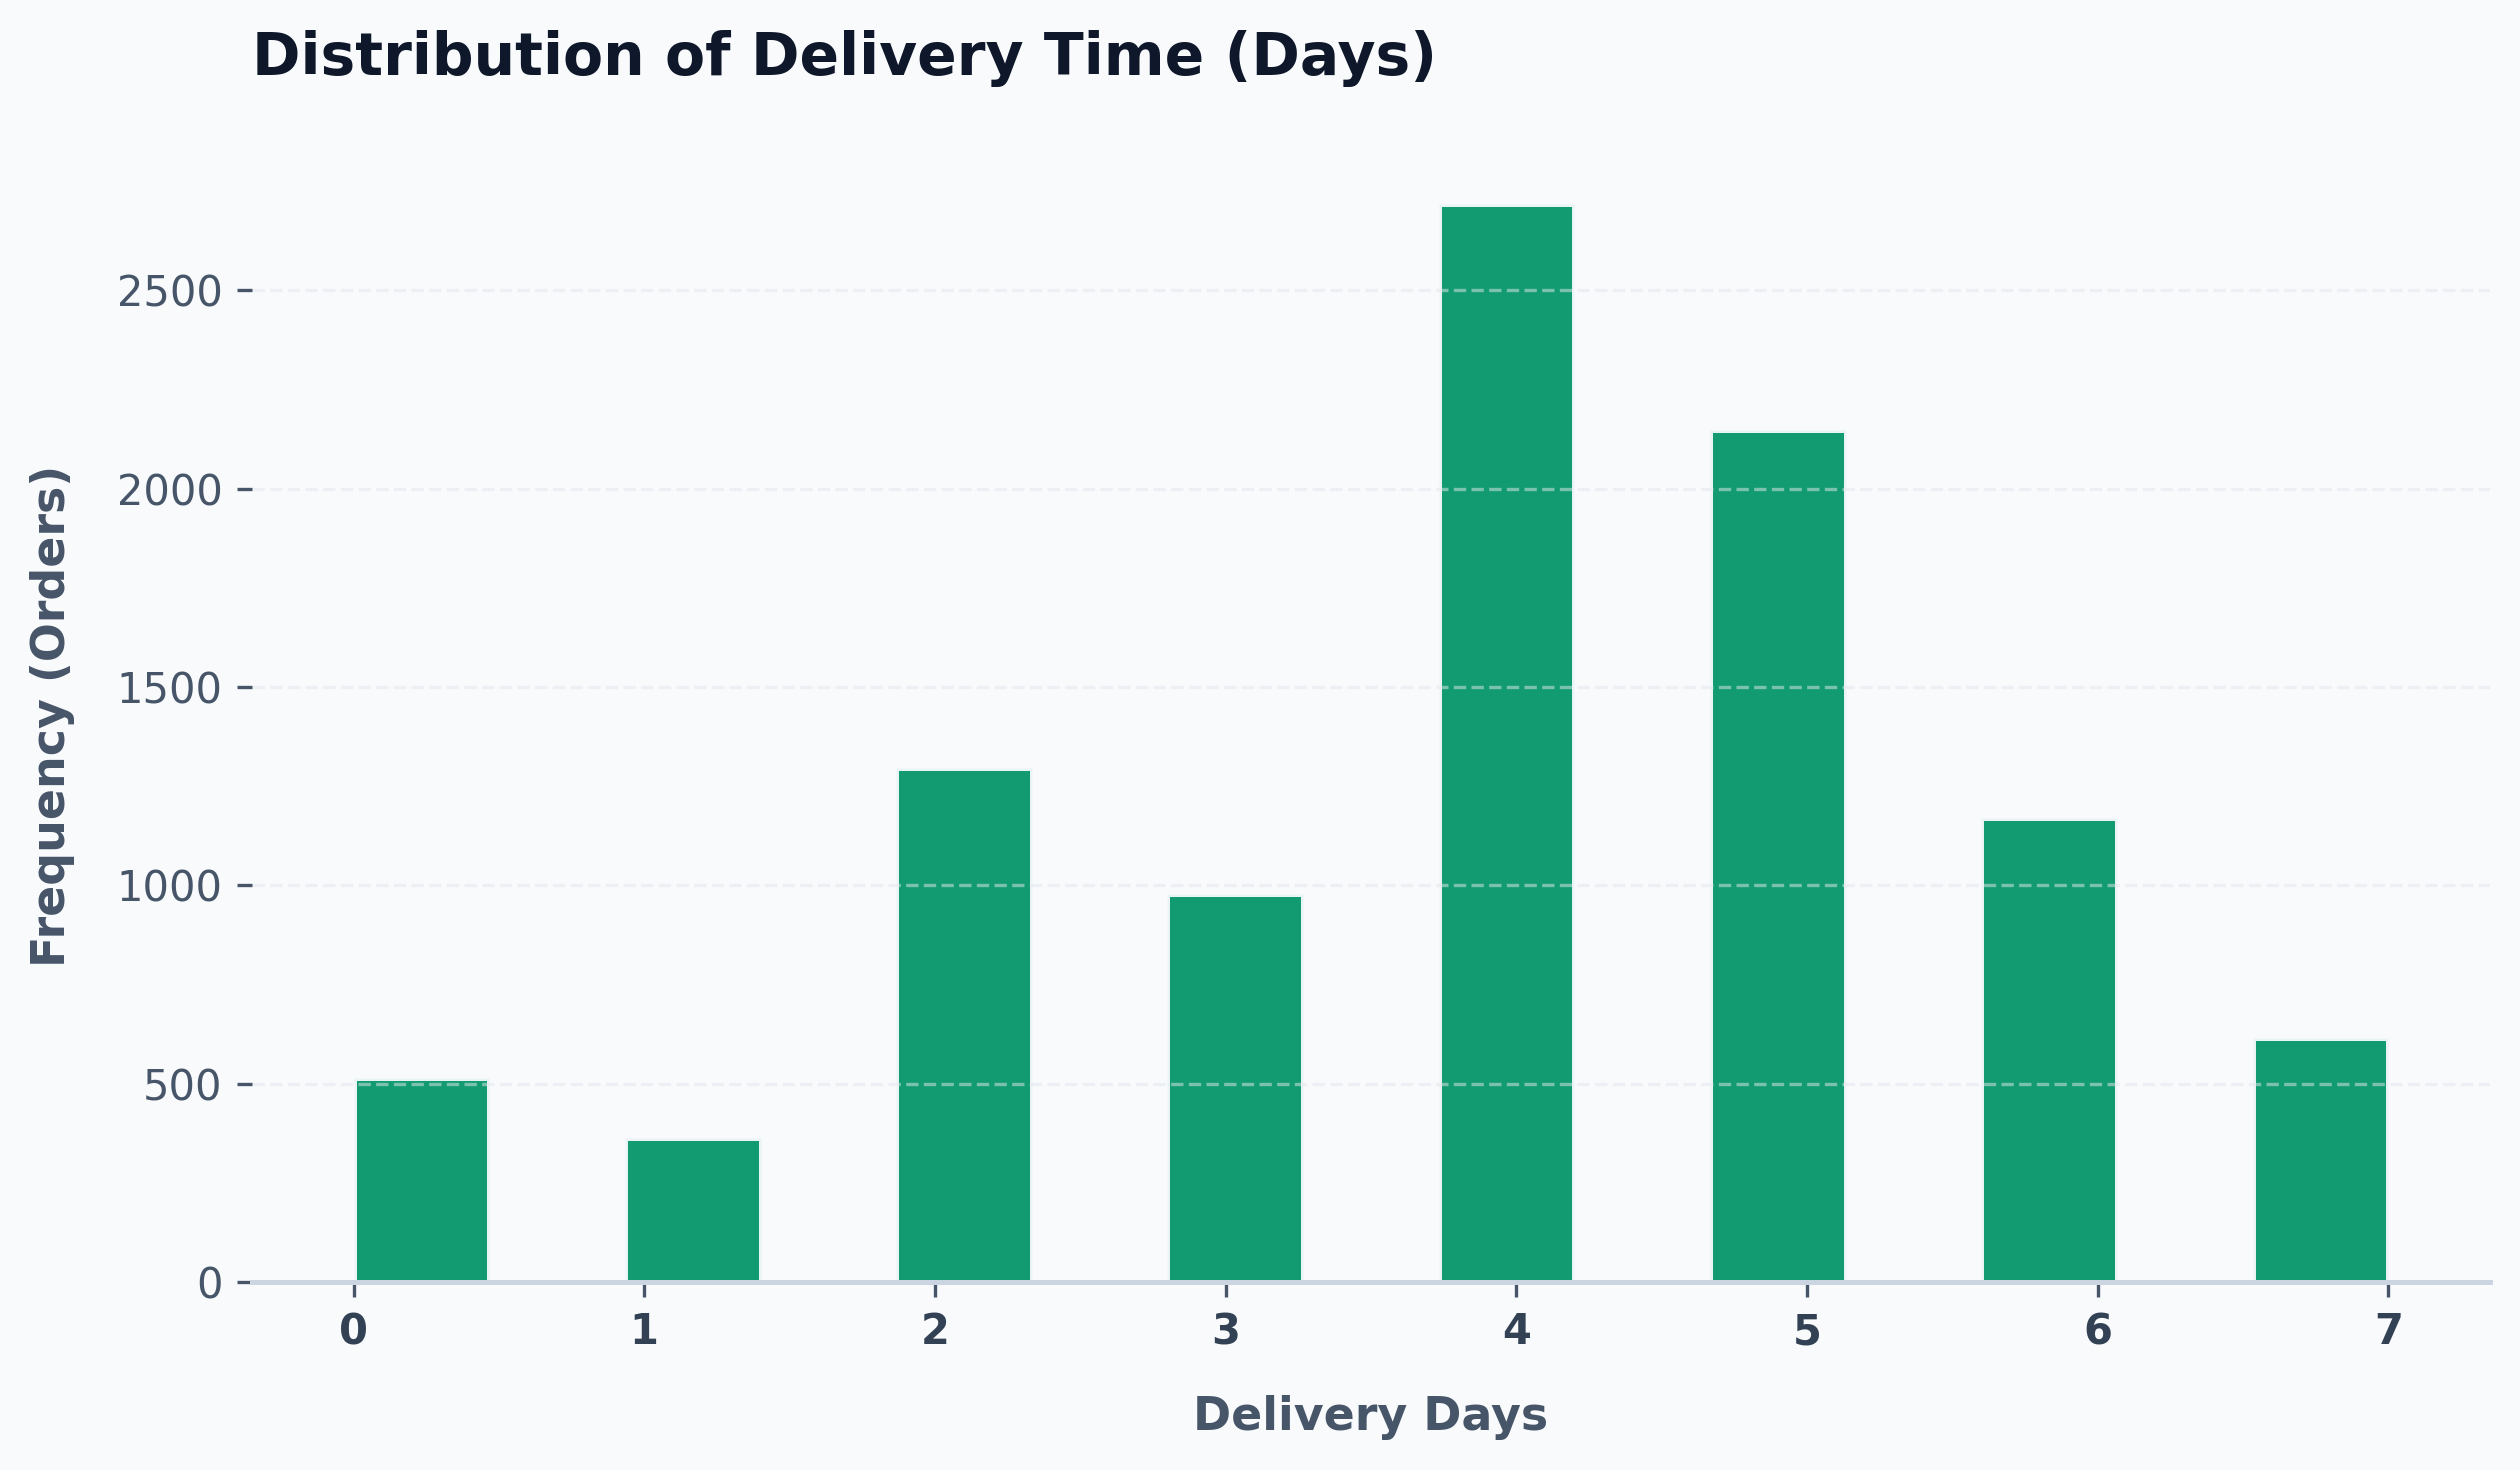

In [8]:
# 1. Setup Figure with Soft Light Card Background
fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)

# Add a soft off-white tint to avoid a harsh white background
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 2. Histogram Plot (Emerald Accent)
n, bins, patches = ax.hist(
    df["Delivery_Days"], 
    bins=15, 
    color="#059669",        # Crisp Emerald Green
    edgecolor="#F8FAFC",    # Clean borders matching the background
    linewidth=1.2,
    alpha=0.95
)

# 3. Spines Styling (Minimalist Clean Look)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CBD5E1")
ax.spines["bottom"].set_linewidth(1.2)

# 4. Grid & Ticks
ax.tick_params(colors="#475569", labelsize=10)
plt.xticks(fontsize=10, fontweight="bold", color="#334155")
plt.yticks(fontsize=10, color="#475569")

# Add soft horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5, color="#E2E8F0")

# 5. Title & Labels
plt.title(
    "Distribution of Delivery Time (Days)", 
    fontsize=14, 
    fontweight="bold", 
    color="#0F172A",
    pad=18, 
    loc="left"
)
plt.xlabel("Delivery Days", fontsize=11, fontweight="bold", color="#475569", labelpad=10)
plt.ylabel("Frequency (Orders)", fontsize=11, fontweight="bold", color="#475569", labelpad=10)

# 6. Save & Display
plt.tight_layout()
plt.savefig(
    "../reports/charts/delivery_time_distribution.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight"
)

plt.show()

> + Average Delivery Time by Shipping Mode

Ship_Mode
Same Day          0.044610
First Class       2.179214
Second Class      3.249211
Standard Class    5.008363
Name: Delivery_Days, dtype: float64


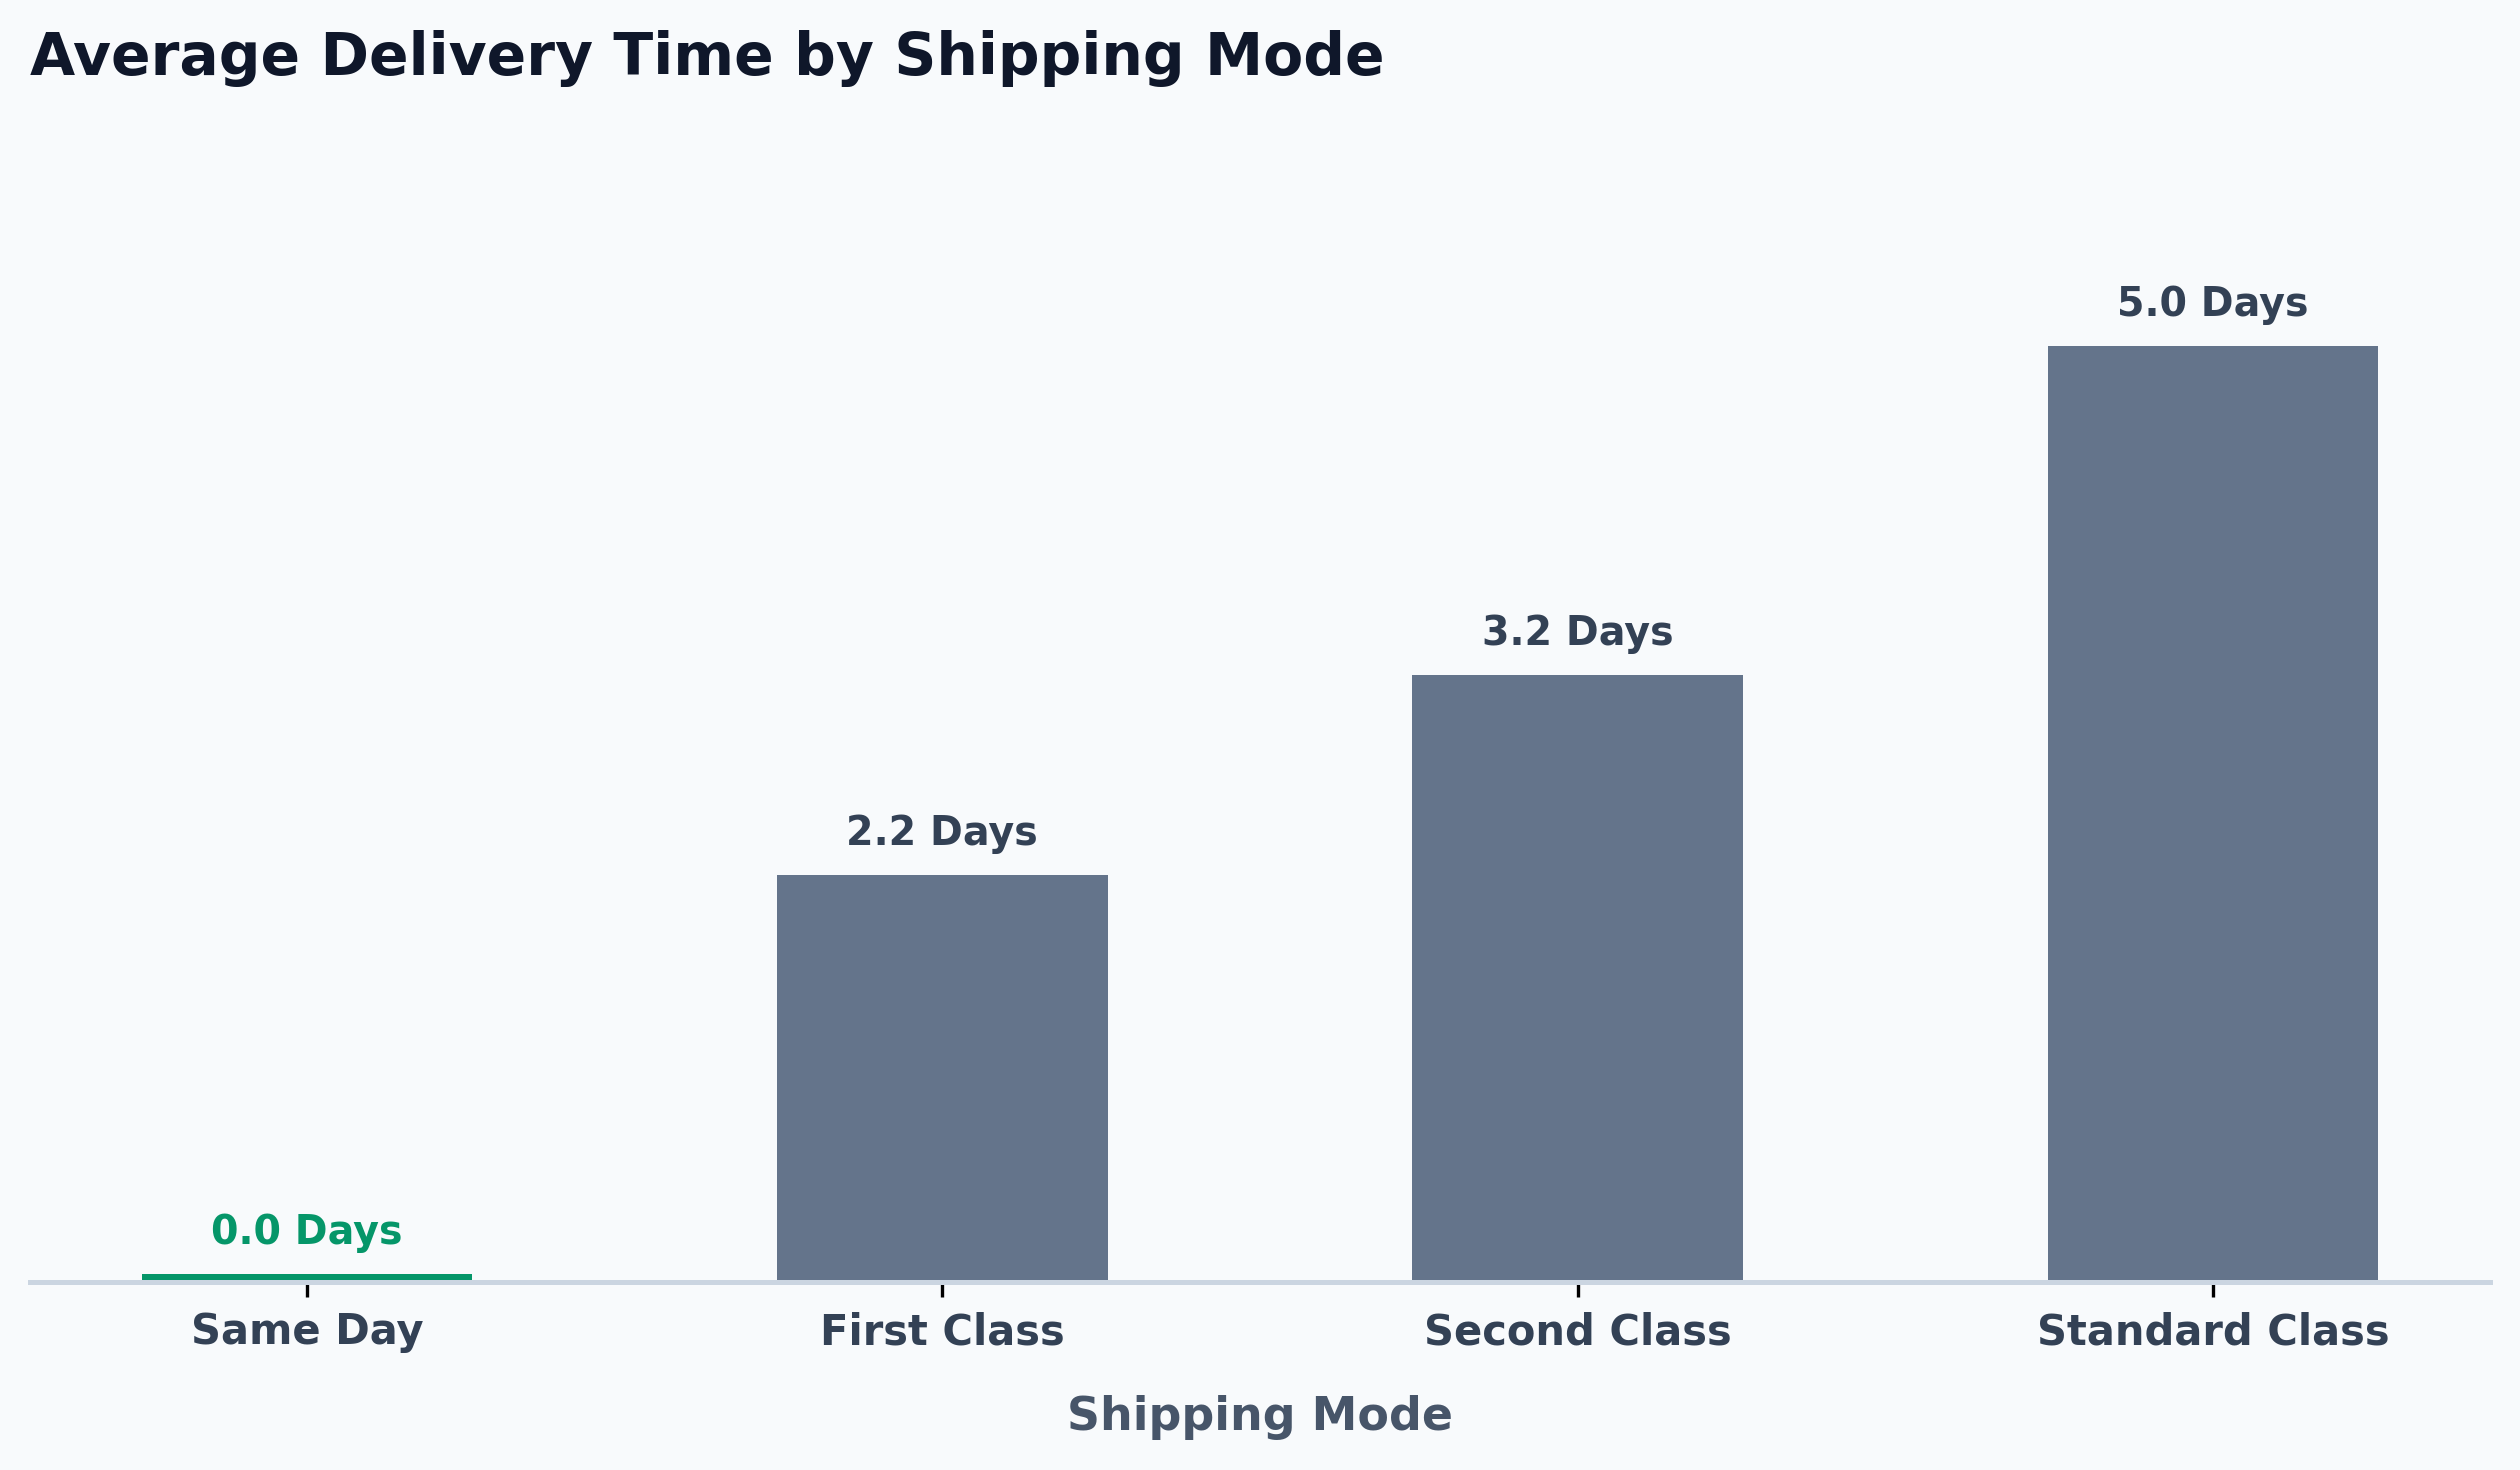

In [9]:
# 1. Group & Sort Average Delivery Days
avg_delivery_by_mode = df.groupby("Ship_Mode")["Delivery_Days"].mean().sort_values()
print(avg_delivery_by_mode)

# 2. Dynamic Highlight Colors (Fastest/Lowest Avg = Emerald Green, Rest = Slate)
min_val = avg_delivery_by_mode.min()
bar_colors = ["#059669" if val == min_val else "#64748B" for val in avg_delivery_by_mode.values]

# 3. Setup Figure with Light Executive Card Background
fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 4. Bar Plot
bars = ax.bar(
    avg_delivery_by_mode.index,
    avg_delivery_by_mode.values,
    color=bar_colors,
    width=0.52,
    edgecolor="none"
)

# 5. Direct Bar Labels (Formatted with 1 Decimal Place)
ax.bar_label(
    bars,
    labels=[f"{val:.1f} Days" for val in avg_delivery_by_mode.values],
    padding=5,
    fontsize=9.5,
    fontweight="bold"
)

# Color Top/Fastest Bar Label Emerald Green
for text, val in zip(ax.texts, avg_delivery_by_mode.values):
    if val == min_val:
        text.set_color("#059669")
    else:
        text.set_color("#334155")

# 6. Spines & Axes Cleanliness
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CBD5E1")
ax.spines["bottom"].set_linewidth(1.2)

# Hide the Y-axis because direct values are displayed on the bars
ax.get_yaxis().set_visible(False)
ax.set_ylim(0, avg_delivery_by_mode.max() * 1.20)

plt.xticks(rotation=0, fontsize=10, fontweight="bold", color="#334155")

# 7. Title & Labels
plt.title(
    "Average Delivery Time by Shipping Mode", 
    fontsize=14, 
    fontweight="bold", 
    color="#0F172A",
    pad=20, 
    loc="left"
)
plt.xlabel("Shipping Mode", fontsize=11, fontweight="bold", color="#475569", labelpad=10)

# Soft Horizontal Grid
plt.grid(axis="y", linestyle="--", alpha=0.5, color="#E2E8F0")

# 8. Save & Display
plt.tight_layout()
plt.savefig(
    "../reports/charts/delivery_by_shipmode.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight"
)

plt.show()

## Region-wise Shipping Behavio

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Delivery_Days, dtype: float64


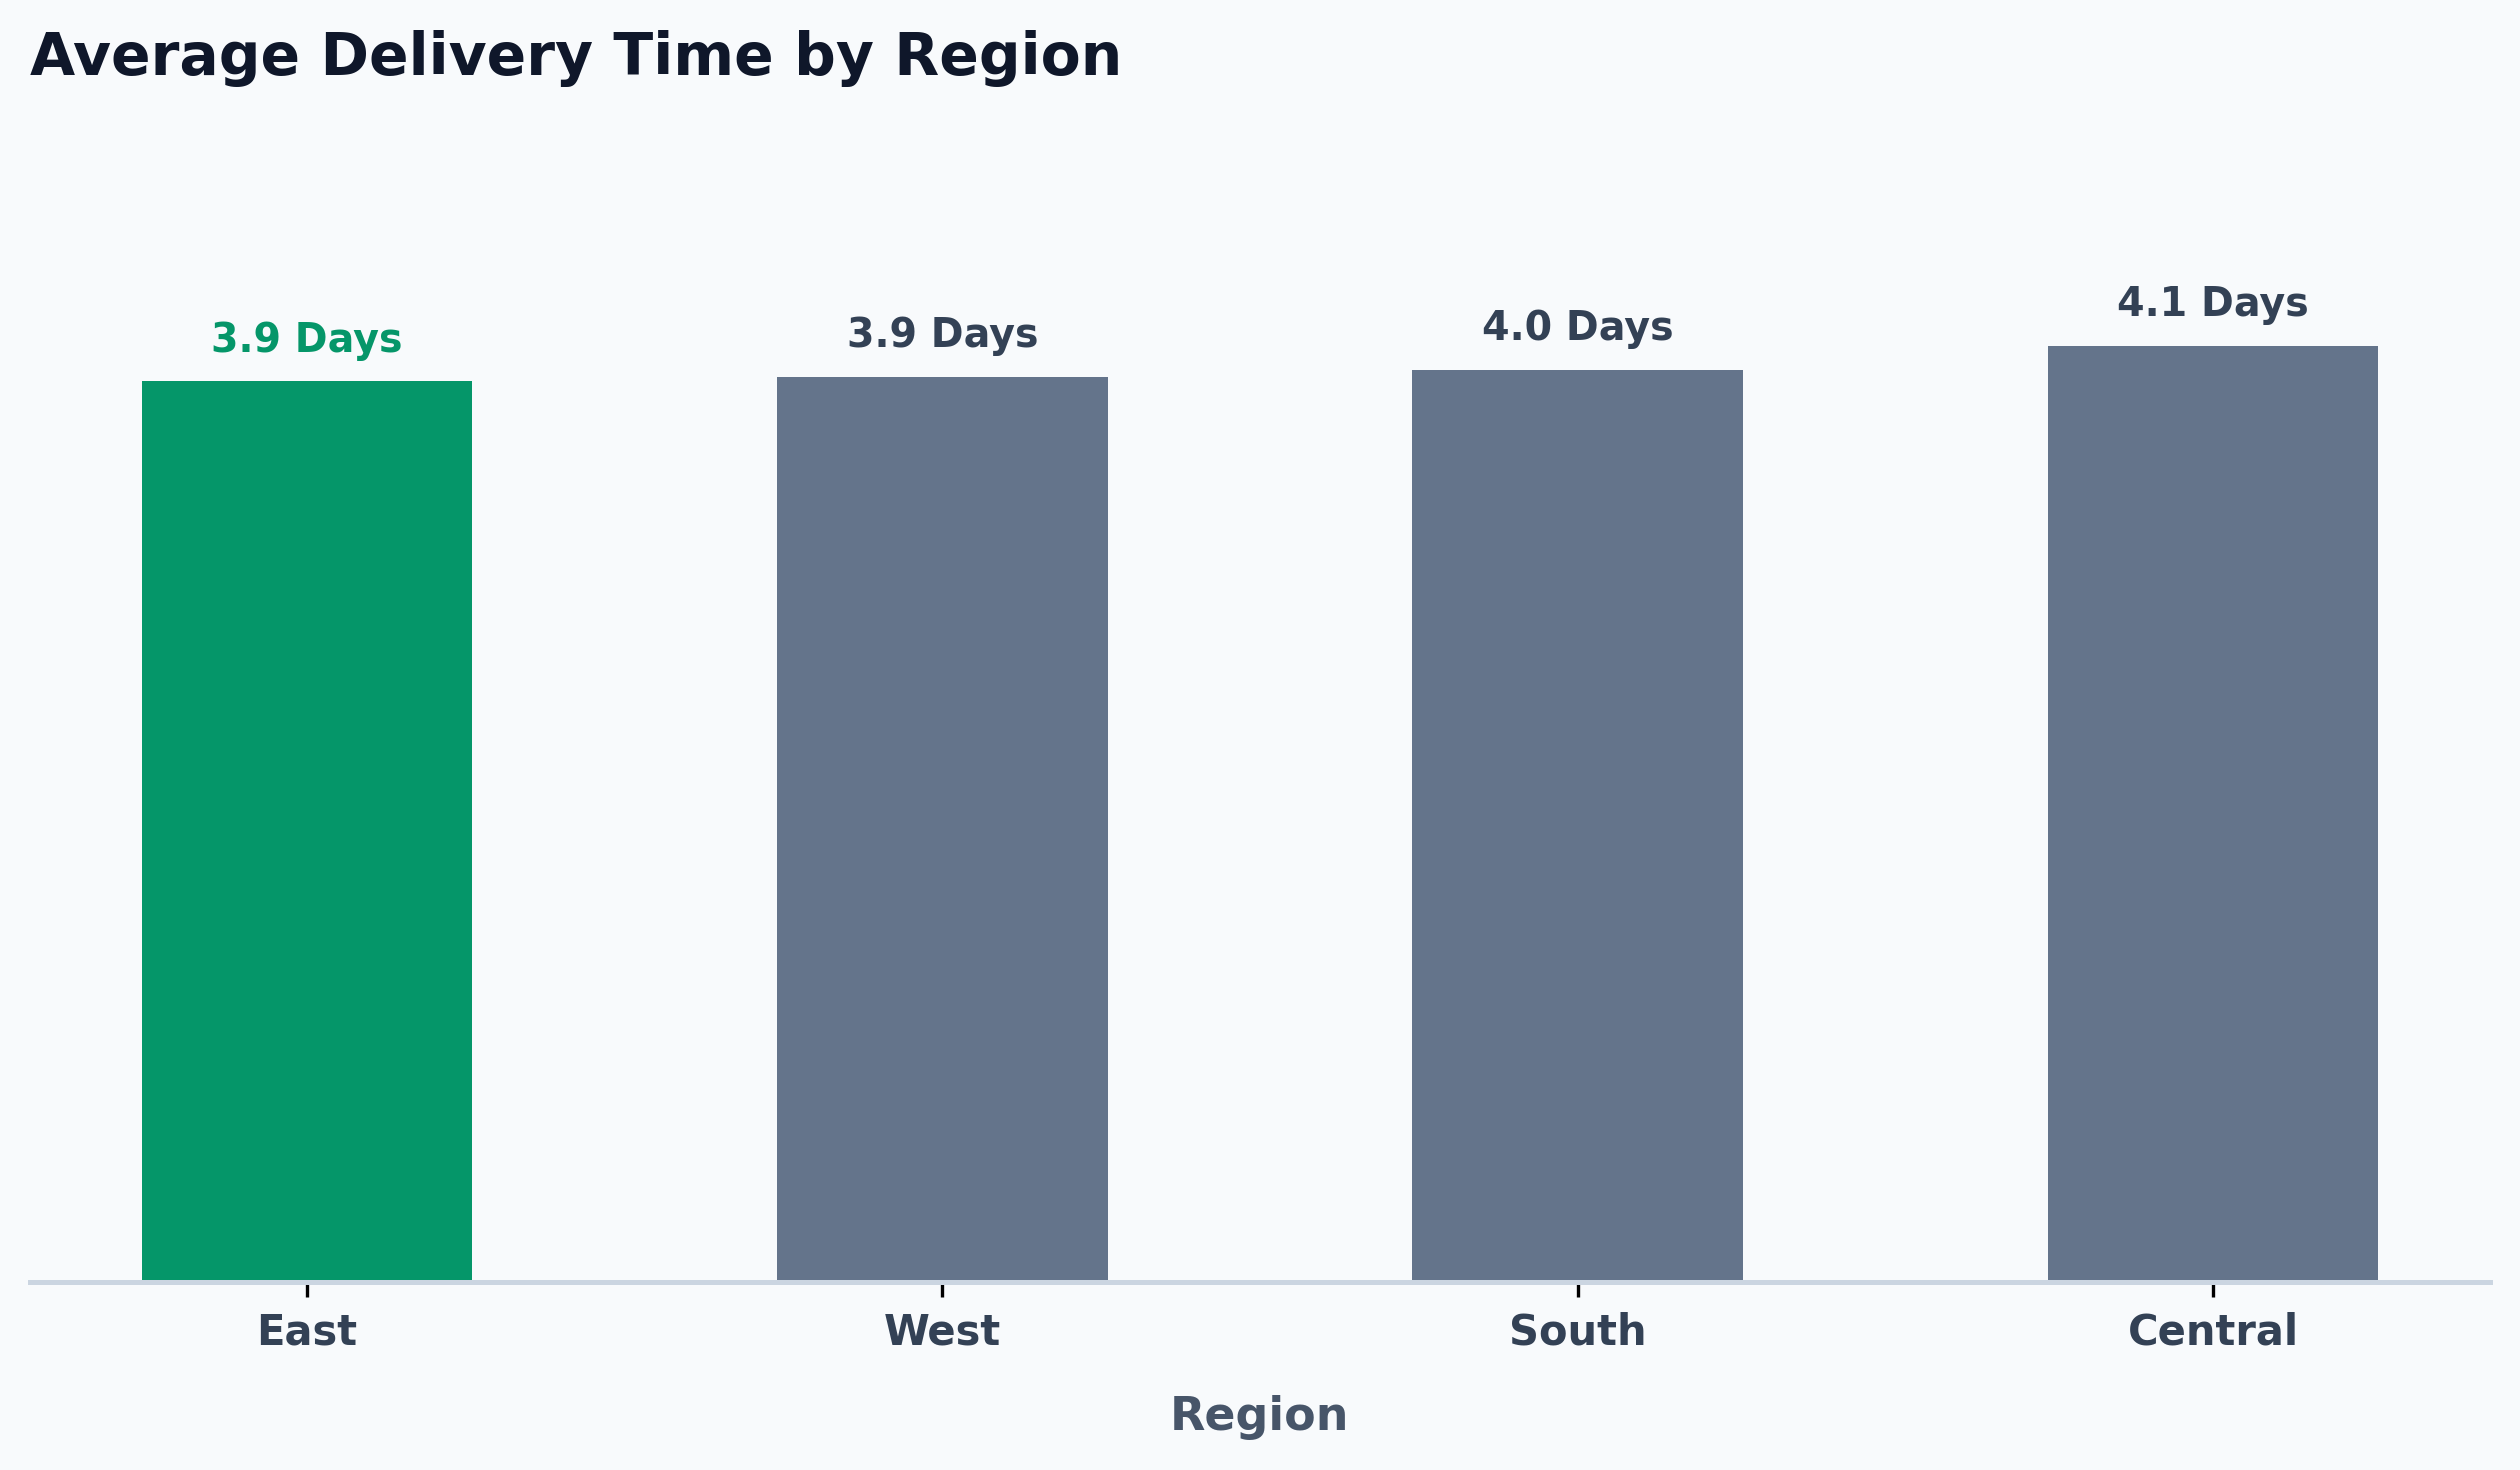

In [10]:
# 1. Group & Sort Average Delivery Days by Region
region_delivery = df.groupby("Region")["Delivery_Days"].mean().sort_values()
print(region_delivery)

# 2. Dynamic Highlight Colors (Fastest/Lowest Avg = Emerald Green, Rest = Slate)
min_val = region_delivery.min()
bar_colors = ["#059669" if val == min_val else "#64748B" for val in region_delivery.values]

# 3. Setup Figure with Light Executive Card Background
fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 4. Bar Plot
bars = ax.bar(
    region_delivery.index,
    region_delivery.values,
    color=bar_colors,
    width=0.52,
    edgecolor="none"
)

# 5. Direct Bar Labels (Formatted with 1 Decimal Place)
ax.bar_label(
    bars,
    labels=[f"{val:.1f} Days" for val in region_delivery.values],
    padding=5,
    fontsize=9.5,
    fontweight="bold"
)

# Color Top/Fastest Bar Label Emerald Green
for text, val in zip(ax.texts, region_delivery.values):
    if val == min_val:
        text.set_color("#059669")
    else:
        text.set_color("#334155")

# 6. Spines & Axes Cleanliness
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CBD5E1")
ax.spines["bottom"].set_linewidth(1.2)

# Hide the redundant Y-axis
ax.get_yaxis().set_visible(False)
ax.set_ylim(0, region_delivery.max() * 1.20)

plt.xticks(rotation=0, fontsize=10, fontweight="bold", color="#334155")

# 7. Title & Labels
plt.title(
    "Average Delivery Time by Region", 
    fontsize=14, 
    fontweight="bold", 
    color="#0F172A",
    pad=20, 
    loc="left"
)
plt.xlabel("Region", fontsize=11, fontweight="bold", color="#475569", labelpad=10)

# Soft Horizontal Grid
plt.grid(axis="y", linestyle="--", alpha=0.5, color="#E2E8F0")

# 8. Save & Display
plt.tight_layout()
plt.savefig(
    "../reports/charts/delivery_by_region.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight"
)

plt.show()

> + Unusually slow region

In [11]:
# Find the region with the highest average delivery time
slowest_region = region_delivery.idxmax()
slowest_value = region_delivery.max()

print(f"Slowest region: {slowest_region} with average {slowest_value:.2f} days")

Slowest region: Central with average 4.07 days


> + Region + Ship_Mode combo heatmap

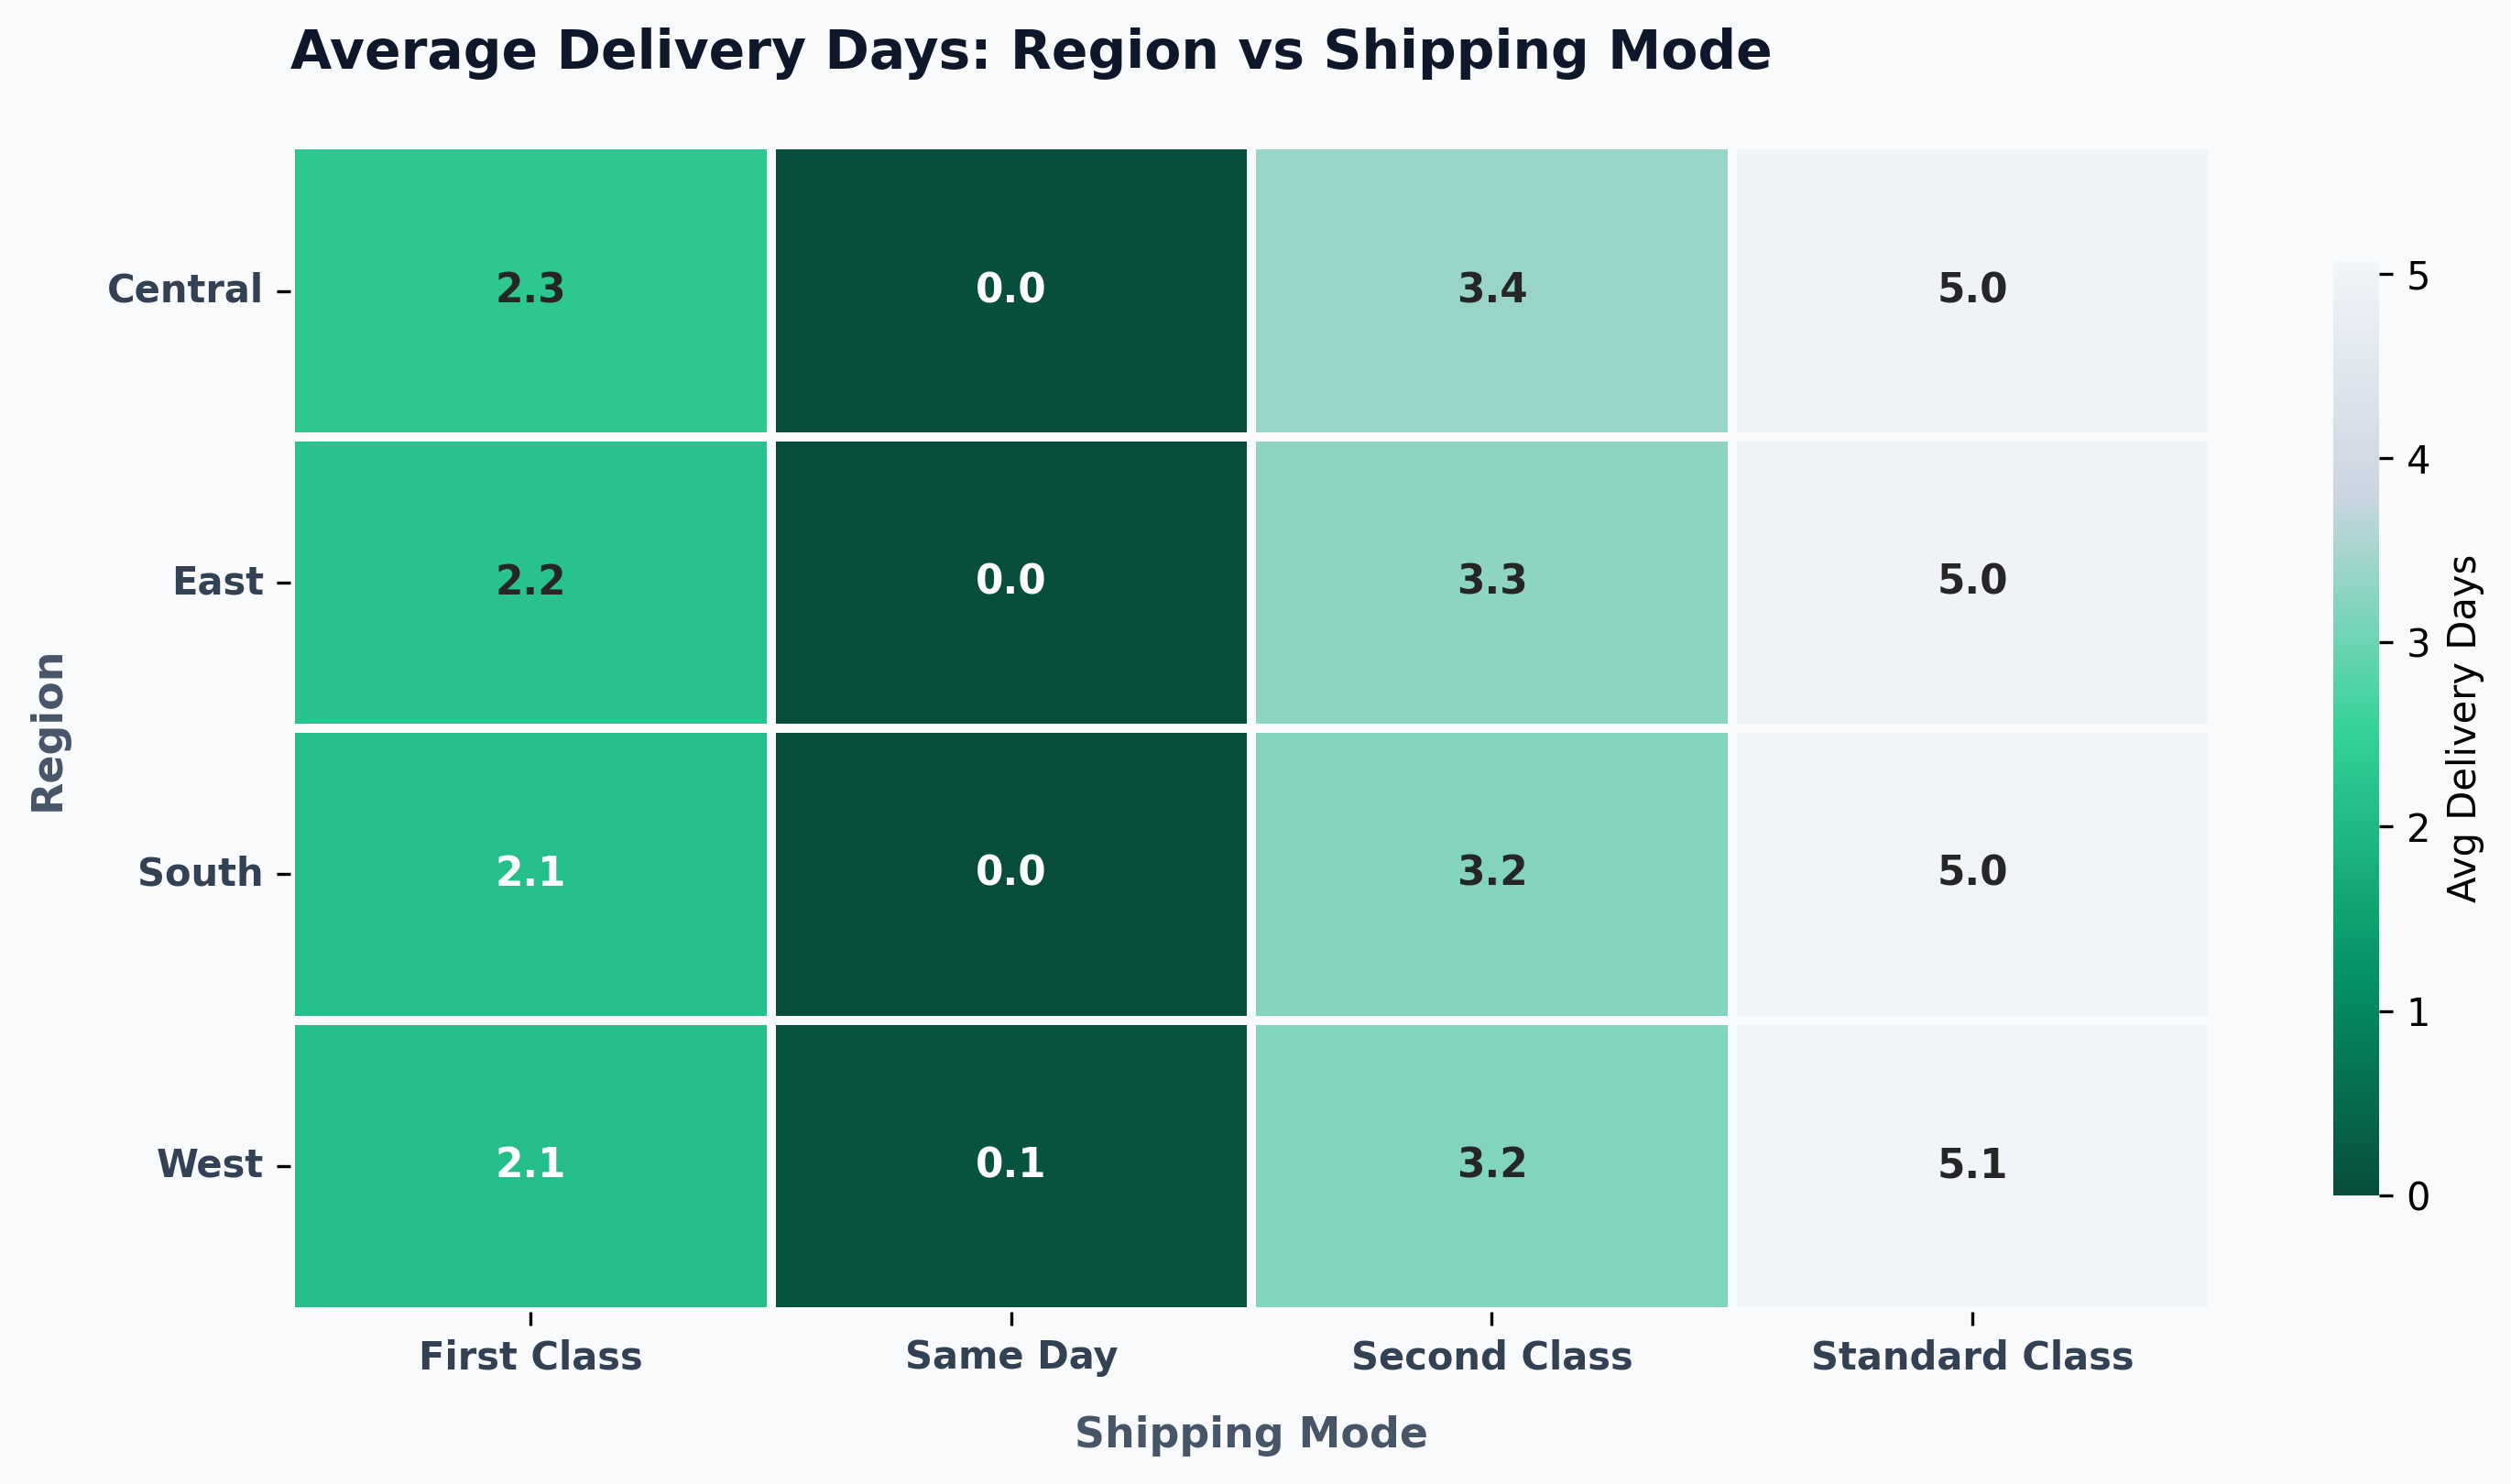

In [12]:
from matplotlib.colors import LinearSegmentedColormap

# 1. Pivot Table Aggregation
region_shipmode_pivot = df.pivot_table(
    index="Region",
    columns="Ship_Mode",
    values="Delivery_Days",
    aggfunc="mean"
)

# 2. Custom Sequential Emerald Colormap (Lower days = Deep Emerald, Higher days = Light Slate)
emerald_cmap = LinearSegmentedColormap.from_list(
    "executive_emerald_rev", 
    ["#064E3B", "#059669", "#34D399", "#CBD5E1", "#F1F5F9"]
)

# 3. Setup Figure with Light Executive Card Background
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 4. Seaborn Heatmap Plot
sns.heatmap(
    region_shipmode_pivot,
    annot=True,
    fmt=".1f",
    cmap=emerald_cmap,
    linewidths=2,             # Clean grid separation
    linecolor="#F8FAFC",      # Grid matching card background
    cbar_kws={
        "label": "Avg Delivery Days",
        "shrink": 0.8
    },
    annot_kws={
        "fontsize": 10.5,
        "fontweight": "bold"
    },
    ax=ax
)

# 5. Axes & Labels Styling
plt.title(
    "Average Delivery Days: Region vs Shipping Mode", 
    fontsize=14, 
    fontweight="bold", 
    color="#0F172A",
    pad=20, 
    loc="left"
)
plt.xlabel("Shipping Mode", fontsize=11, fontweight="bold", color="#475569", labelpad=10)
plt.ylabel("Region", fontsize=11, fontweight="bold", color="#475569", labelpad=10)

plt.xticks(rotation=0, fontsize=10, fontweight="bold", color="#334155")
plt.yticks(rotation=0, fontsize=10, fontweight="bold", color="#334155")

# 6. Save & Display (Retaining Card Background)
plt.tight_layout()
plt.savefig(
    "../reports/charts/region_shipmode_heatmap.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight"
)

plt.show()

## 🚚 Shipping Analysis Summary

### Shipping Mode Usage
- Most used shipping mode: `Standard Class` (`5,859 orders`)
- Highest revenue-generating mode: `Standard Class`

### Delivery Time
- Overall average delivery time: `3.96 days`
- Fastest mode: `Same Day` (`0.04 days avg`)
- Slowest mode: `Standard Class` (`5.01 days avg`)

### Regional Shipping Behavior
- Fastest region: `East` (`3.91 days avg`)
- Slowest region: `Central` (`4.07 days avg`) — potential logistics issue

### 💡 Business Insight

`Standard Class` is the most commonly used shipping mode, accounting for
`59.79%` of all orders. This suggests that most customers may prioritize
cost and convenience over faster delivery. However, the `Central` region
shows noticeably slower delivery times (`4.07 days avg`), which may indicate
warehouse or logistics inefficiencies in that area and could affect customer
experience.

The business should investigate fulfillment processes in the `Central`
region and consider whether faster shipping options should be promoted more
actively to customers.